In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine, types
from sqlalchemy import text # to be able to pass string

# 1. Set up connection (update credentials and host!)
from dotenv import dotenv_values

config = dotenv_values() 

# define variables for the login
pg_user = config['POSTGRES_USER']  # align the key label with your .env file !
pg_host = config['POSTGRES_HOST']
pg_port = config['POSTGRES_PORT']
pg_db = config['POSTGRES_DB']
pg_schema = config['POSTGRES_SCHEMA']
pg_pass = config['POSTGRES_PASS']

url = f'postgresql://{pg_user}:{pg_pass}@{pg_host}:{pg_port}/{pg_db}'

engine = create_engine(url, echo=False)

# 2. Load data

my_schema = "team_3"

mart_all_data = pd.read_sql(
    f"SELECT * FROM {my_schema}.mart_all_data;",
    engine,
    parse_dates=['transaction_date']
)

# Customer demographic data (for segmentation)
mart_customers = pd.read_sql(
    f"SELECT * FROM {my_schema}.mart_customers;",
    engine
)

In [28]:
mart_all_data.head()


,transaction_date,transaction_id,customer_id,customer_gender,customer_location,customer_tenure_months,produkt_sku,product_category,quantity,avg_price,delivery_charges,revenue,coupon_status,discount_pct,gst_onsale,daily_offline,daily_online,transaction_month,transaction_month_str
0,2019-04-19,25990,15811,F,Illinois,27,GGOEWCKQ085457,Accessories,1,16.99,6.0,22.99,Clicked,10.0,0.1,4000,1754.92,4.0,apr
1,2019-04-07,25038,17999,F,New Jersey,30,GGOEGBPB081999,Accessories,1,49.99,6.5,56.49,Used,10.0,0.1,2500,2719.46,4.0,apr
2,2019-04-07,25038,17999,F,New Jersey,30,GGOEGBPB082099,Accessories,1,59.99,6.5,66.49,Clicked,10.0,0.1,2500,2719.46,4.0,apr
3,2019-04-28,26637,18116,F,Illinois,38,GGOEGBPB081999,Accessories,1,39.99,6.0,45.99,Clicked,10.0,0.1,3500,2019.73,4.0,apr
4,2019-08-02,34452,16889,F,Illinois,23,GGOEGBPB081999,Accessories,1,34.99,6.0,40.99,Used,20.0,0.1,1500,2155.96,8.0,aug


In [29]:
mart_all_data['revenue'] = mart_all_data['quantity'] * mart_all_data['avg_price'] + mart_all_data['delivery_charges']


In [30]:
mart_all_data.columns

Index(['transaction_date', 'transaction_id', 'customer_id', 'customer_gender',
       'customer_location', 'customer_tenure_months', 'produkt_sku',
       'product_category', 'quantity', 'avg_price', 'delivery_charges',
       'revenue', 'coupon_status', 'discount_pct', 'gst_onsale',
       'daily_offline', 'daily_online', 'transaction_month',
       'transaction_month_str'],
      dtype='object')

In [31]:
# 1. Get each customer’s signup month (=first purchase)

mart_all_data['transaction_date'] = pd.to_datetime(mart_all_data['transaction_date'])
mart_all_data['transaction_month'] = mart_all_data['transaction_date'].dt.to_period('M')
first_orders = mart_all_data.groupby('customer_id')['transaction_month'].min().reset_index()
first_orders = first_orders.rename(columns={'transaction_month': 'signup_month'})
mart_all_data = mart_all_data.merge(first_orders, on='customer_id', how='left')
mart_all_data['cohort_index'] = (mart_all_data['transaction_month'] - mart_all_data['signup_month']).apply(lambda x: x.n)


In [32]:
# 1. Get each customer’s signup month
mart_all_data['transaction_month'] = mart_all_data['transaction_date'].dt.to_period('M')

first_orders = (
    mart_all_data.groupby('customer_id')['transaction_month']
    .min()
    .reset_index()
    .rename(columns={'transaction_month': 'signup_month'})
)

# 2. Build orders table (customer_id, transaction_month, signup_month)
orders = mart_all_data[['customer_id', 'transaction_month']].drop_duplicates()
orders = orders.merge(first_orders, on='customer_id', how='left')
orders['cohort_index'] = (orders['transaction_month'] - orders['signup_month']).apply(lambda x: x.n)



Cohort Pivot Table (Retention Matrix)

In [33]:

#Retention Matrix (Customers Retained Each Month)
cohort_counts = (
    mart_all_data.groupby(['signup_month', 'cohort_index'])['customer_id']
    .nunique()
    .reset_index()
    .pivot(index='signup_month', columns='cohort_index', values='customer_id')
)



In [34]:
# Calculate retention as % of original cohort size
cohort_size = cohort_counts.iloc[:, 0]
retention = cohort_counts.divide(cohort_size, axis=0).round(3) * 100
print("Retention Matrix (%):")
print(retention)

Retention Matrix (%):
cohort_index     0     1     2     3     4     5     6     7     8     9   \
signup_month                                                                
2019-01       100.0   6.0  11.2  15.8  10.7  20.5  16.3  21.9  10.7  13.0   
2019-02       100.0   7.3   9.4  16.7  17.7  22.9  19.8  15.6  12.5  11.5   
2019-03       100.0  10.2  19.8  14.1  18.1  18.6  12.4  12.4   8.5  10.7   
2019-04       100.0   8.6  14.7  14.7  11.0   9.2   6.1   9.8   7.4   NaN   
2019-05       100.0  10.7   8.0  11.6   8.9  11.6  12.5   7.1   NaN   NaN   
2019-06       100.0  14.6  16.1   8.8   8.0  10.2   8.0   NaN   NaN   NaN   
2019-07       100.0  13.8   4.3   6.4  11.7   9.6   NaN   NaN   NaN   NaN   
2019-08       100.0  10.4  11.1   7.4   5.9   NaN   NaN   NaN   NaN   NaN   
2019-09       100.0   7.7   3.8   2.6   NaN   NaN   NaN   NaN   NaN   NaN   
2019-10       100.0   6.9   4.6   NaN   NaN   NaN   NaN   NaN   NaN   NaN   
2019-11       100.0  10.3   NaN   NaN   NaN   NaN   Na

In [35]:
#Cohort Revenue Matrix
cohort_revenue = (
    mart_all_data.groupby(['signup_month', 'cohort_index'])['revenue']
    .sum()
    .reset_index()
    .pivot(index='signup_month', columns='cohort_index', values='revenue')
)
print("Cohort Revenue (total revenue per cohort per period):")
print(cohort_revenue)

Cohort Revenue (total revenue per cohort per period):
cohort_index         0         1         2          3         4         5   \
signup_month                                                                 
2019-01       462866.90  45272.03  58542.51  122221.36  34476.56  58699.00   
2019-02       314764.37   9751.88  14331.18   25113.18  26551.65  47446.90   
2019-03       342113.64  44608.13  40717.04   33580.92  52847.02  78221.45   
2019-04       261939.49  25695.19  18324.83   33470.91  28985.33  32875.04   
2019-05       223157.62   7491.65  14005.50   17177.14  18788.38  40526.46   
2019-06       213946.91  12455.86  15026.99   17970.72  11300.86  39562.22   
2019-07       168033.12  16596.97   7900.86   15887.85  25418.87  30882.73   
2019-08       220855.86  11490.20  12089.15   30635.96  17769.68       NaN   
2019-09       164597.74   2029.95   2747.33     720.79       NaN       NaN   
2019-10       244227.80  10396.37   3062.82        NaN       NaN       NaN   
2019-11   

In [36]:
#LTV Matrix (Cumulative Revenue Per Customer in Cohort)
cumulative_revenue = cohort_revenue.cumsum(axis=1)
cumulative_ltv = cumulative_revenue.divide(cohort_size, axis=0).round(2)
print("Cumulative LTV Matrix (Avg. $ per original cohort member):")
print(cumulative_ltv)

Cumulative LTV Matrix (Avg. $ per original cohort member):
cohort_index       0        1        2        3        4        5        6   \
signup_month                                                                  
2019-01       2152.87  2363.44  2635.73  3204.20  3364.56  3637.57  4070.61   
2019-02       3278.80  3380.38  3529.66  3791.26  4067.84  4562.07  4849.00   
2019-03       1932.85  2184.87  2414.91  2604.63  2903.20  3345.13  3642.33   
2019-04       1606.99  1764.63  1877.05  2082.40  2260.22  2461.91  2567.70   
2019-05       1992.48  2059.37  2184.42  2337.78  2505.54  2867.38  3226.57   
2019-06       1561.66  1652.57  1762.26  1893.43  1975.92  2264.70  2386.39   
2019-07       1787.59  1964.15  2048.20  2217.22  2487.63  2816.17      NaN   
2019-08       1635.97  1721.08  1810.63  2037.56  2169.19      NaN      NaN   
2019-09       2110.23  2136.25  2171.47  2180.72      NaN      NaN      NaN   
2019-10       2807.22  2926.71  2961.92      NaN      NaN      NaN      

In [37]:
#Revenue Per Retained Customer
revenue_per_retained = cohort_revenue.divide(cohort_counts).round(2)
print("Revenue Per Retained Customer (only those active in each period):")
print(revenue_per_retained)

Revenue Per Retained Customer (only those active in each period):
cohort_index       0        1        2        3        4        5        6   \
signup_month                                                                  
2019-01       2152.87  3482.46  2439.27  3594.75  1498.98  1334.07  2660.08   
2019-02       3278.80  1393.13  1592.35  1569.57  1561.86  2156.68  1449.75   
2019-03       1932.85  2478.23  1163.34  1343.24  1651.47  2370.35  2391.06   
2019-04       1606.99  1835.37   763.53  1394.62  1610.30  2191.67  1724.38   
2019-05       1992.48   624.30  1556.17  1321.32  1878.84  3117.42  2873.47   
2019-06       1561.66   622.79   683.04  1497.56  1027.35  2825.87  1515.59   
2019-07       1787.59  1276.69  1975.22  2647.98  2310.81  3431.41      NaN   
2019-08       1635.97   820.73   805.94  3063.60  2221.21      NaN      NaN   
2019-09       2110.23   338.32   915.78   360.40      NaN      NaN      NaN   
2019-10       2807.22  1732.73   765.70      NaN      NaN      Na

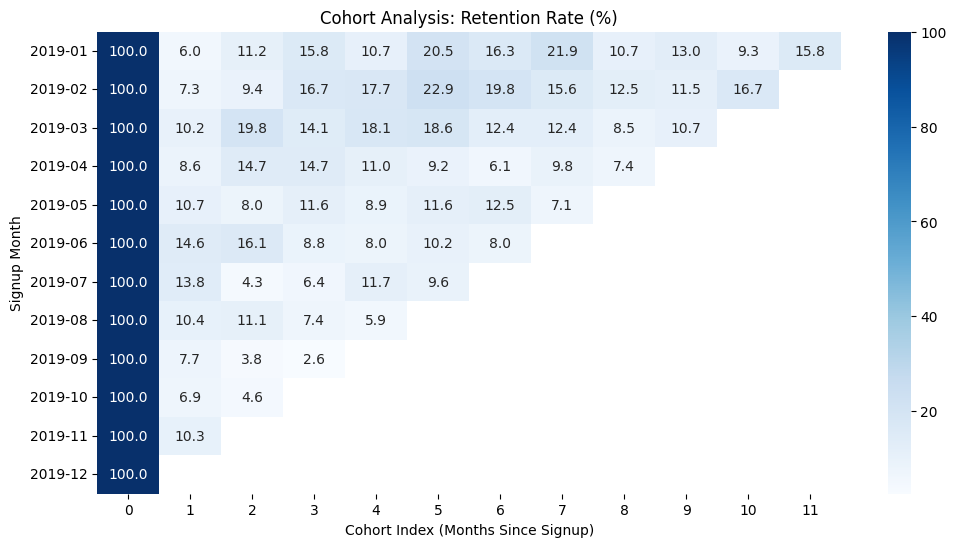

In [38]:
# Retention Heatmap

plt.figure(figsize=(12, 6))
sns.heatmap(retention, annot=True, fmt='.1f', cmap='Blues')
plt.title('Cohort Analysis: Retention Rate (%)')
plt.xlabel('Cohort Index (Months Since Signup)')
plt.ylabel('Signup Month')
plt.show()

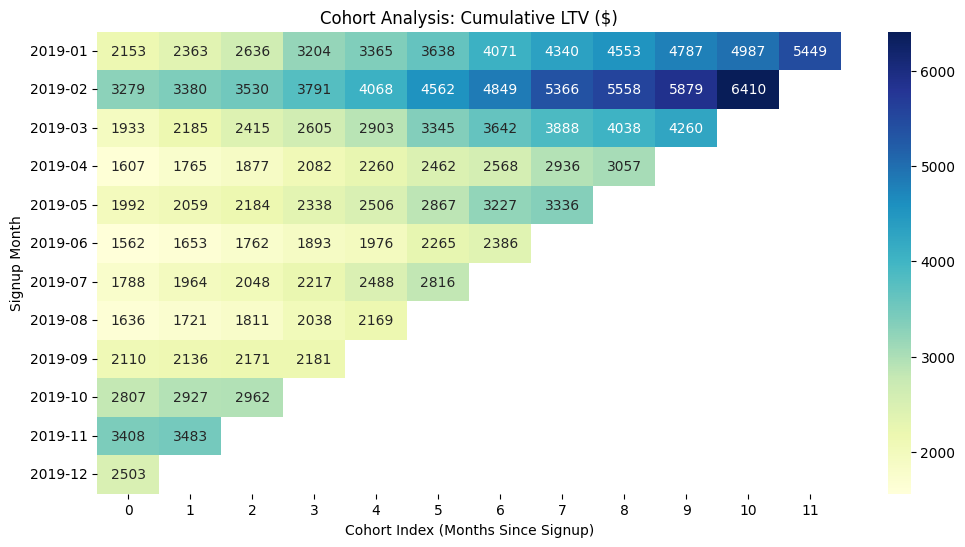

In [39]:
#Cumulative LTV Heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(cumulative_ltv, annot=True, fmt='.0f', cmap='YlGnBu')
plt.title('Cohort Analysis: Cumulative LTV ($)')
plt.xlabel('Cohort Index (Months Since Signup)')
plt.ylabel('Signup Month')
plt.show()

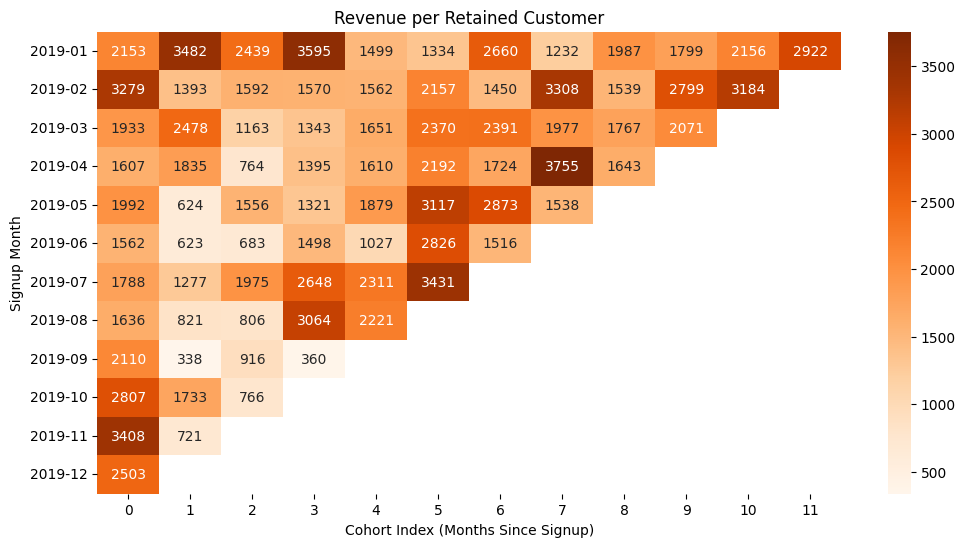

In [40]:
#Revenue Per Retained Customer Heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(revenue_per_retained, annot=True, fmt='.0f', cmap='Oranges')
plt.title('Revenue per Retained Customer')
plt.xlabel('Cohort Index (Months Since Signup)')
plt.ylabel('Signup Month')
plt.show()


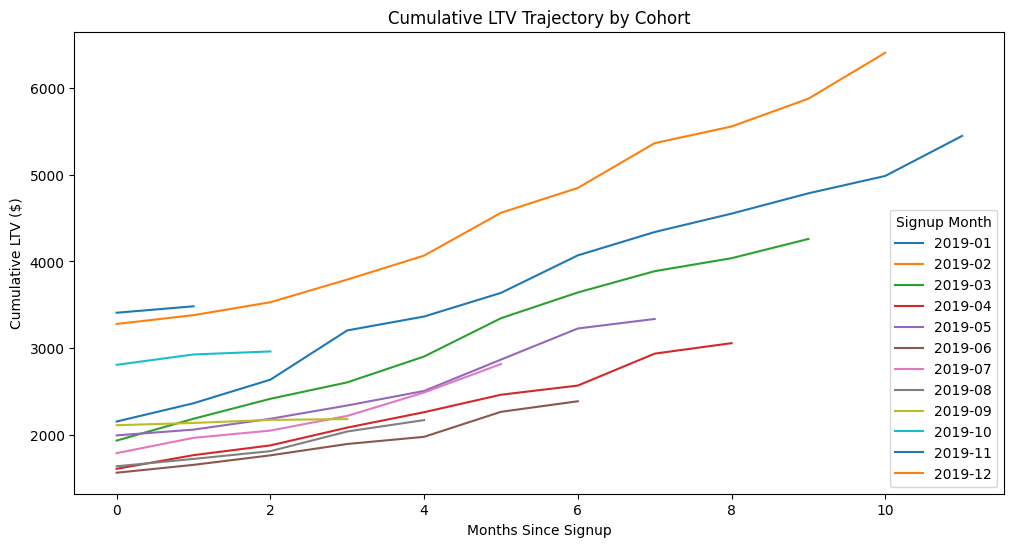

In [41]:
#Compare Cohort Revenue Trajectories
plt.figure(figsize=(12, 6))
for i, row in cumulative_ltv.iterrows():
    plt.plot(row.values, label=str(i))
plt.title('Cumulative LTV Trajectory by Cohort')
plt.xlabel('Months Since Signup')
plt.ylabel('Cumulative LTV ($)')
plt.legend(title='Signup Month')
plt.show()

Cohort analysis by gender

In [42]:
mart_all_data = mart_all_data.merge(mart_customers, on='customer_id', how='left')

for seg in mart_all_data['gender'].dropna().unique():
    sub = mart_all_data[mart_all_data['gender'] == seg]
    cohort_counts = (
        sub.groupby(['signup_month', 'cohort_index'])['customer_id']
        .nunique()
        .reset_index()
        .pivot(index='signup_month', columns='cohort_index', values='customer_id')
    )
    cohort_size = cohort_counts.iloc[:, 0]
    retention = cohort_counts.divide(cohort_size, axis=0).round(3) * 100
    print(f"\nRetention Matrix (%) for Gender: {seg}")
    print(retention)


Retention Matrix (%) for Gender: F
cohort_index     0     1     2     3     4     5     6     7     8     9   \
signup_month                                                                
2019-01       100.0   7.8  10.1  14.7   9.3  22.5  15.5  18.6  10.9  12.4   
2019-02       100.0   9.2   9.2  18.5  12.3  24.6  15.4  18.5  12.3   9.2   
2019-03       100.0   9.6  20.9  13.0  16.5  18.3  13.9  13.0   9.6  11.3   
2019-04       100.0   6.9  13.7  13.7  14.7  10.8   3.9  10.8   6.9   NaN   
2019-05       100.0  10.7   8.0  13.3   9.3   9.3  12.0   4.0   NaN   NaN   
2019-06       100.0  15.3  17.6   9.4   5.9  10.6   5.9   NaN   NaN   NaN   
2019-07       100.0  13.8   1.7   5.2  15.5  10.3   NaN   NaN   NaN   NaN   
2019-08       100.0   9.5  11.9   6.0   4.8   NaN   NaN   NaN   NaN   NaN   
2019-09       100.0  10.8   5.4   5.4   NaN   NaN   NaN   NaN   NaN   NaN   
2019-10       100.0   7.7   4.6   NaN   NaN   NaN   NaN   NaN   NaN   NaN   
2019-11       100.0   9.8   NaN   NaN   

Cohort analysis by AOV_segment

In [43]:
# Calculate each customer's total revenue and number of orders
aov_per_customer = (
    mart_all_data.groupby('customer_id')
    .agg(
        total_revenue=('revenue', 'sum'),
        n_orders=('transaction_id', 'nunique')
    )
    .reset_index()
)
aov_per_customer['AOV'] = aov_per_customer['total_revenue'] / aov_per_customer['n_orders']



In [44]:
#Create AOV Segments (quartiles bins)

aov_per_customer['AOV_segment'] = pd.qcut(
    aov_per_customer['AOV'],
    q=4,
    labels=['Low', 'Medium-Low', 'Medium-High', 'High']
)

In [45]:
#Merge Segment Back to mart_all_data
mart_all_data = mart_all_data.merge(aov_per_customer[['customer_id', 'AOV_segment']], on='customer_id', how='left')


Cohort Analysis Loop

In [46]:
for seg in mart_all_data['AOV_segment'].dropna().unique():
    sub = mart_all_data[mart_all_data['AOV_segment'] == seg]
    cohort_counts = (
        sub.groupby(['signup_month', 'cohort_index'])['customer_id']
        .nunique()
        .reset_index()
        .pivot(index='signup_month', columns='cohort_index', values='customer_id')
    )
    cohort_size = cohort_counts.iloc[:, 0]
    retention = cohort_counts.divide(cohort_size, axis=0).round(3) * 100
    print(f"\nRetention Matrix (%) for AOV Segment: {seg}")
    print(retention)


Retention Matrix (%) for AOV Segment: Low
cohort_index     0    1     2     3     4     5     6     7    8     9     10  \
signup_month                                                                    
2019-01       100.0  2.6   5.3  10.5   7.9   7.9  13.2  18.4  2.6  10.5   NaN   
2019-02       100.0  NaN   5.6  11.1  22.2  22.2  22.2   5.6  5.6   NaN  11.1   
2019-03       100.0  6.7  15.6   6.7  15.6  17.8   8.9   4.4  4.4   NaN   NaN   
2019-04       100.0  5.8  17.3   3.8  11.5   3.8   1.9   3.8  3.8   NaN   NaN   
2019-05       100.0  7.3   7.3   7.3   4.9   7.3   NaN   4.9  NaN   NaN   NaN   
2019-06       100.0  7.7  17.9   5.1   5.1   NaN   5.1   NaN  NaN   NaN   NaN   
2019-07       100.0  6.2   NaN   6.2   3.1   3.1   NaN   NaN  NaN   NaN   NaN   
2019-08       100.0  9.5   7.1   4.8   2.4   NaN   NaN   NaN  NaN   NaN   NaN   
2019-09       100.0  5.3   NaN   NaN   NaN   NaN   NaN   NaN  NaN   NaN   NaN   
2019-10       100.0  NaN   NaN   NaN   NaN   NaN   NaN   NaN  NaN 

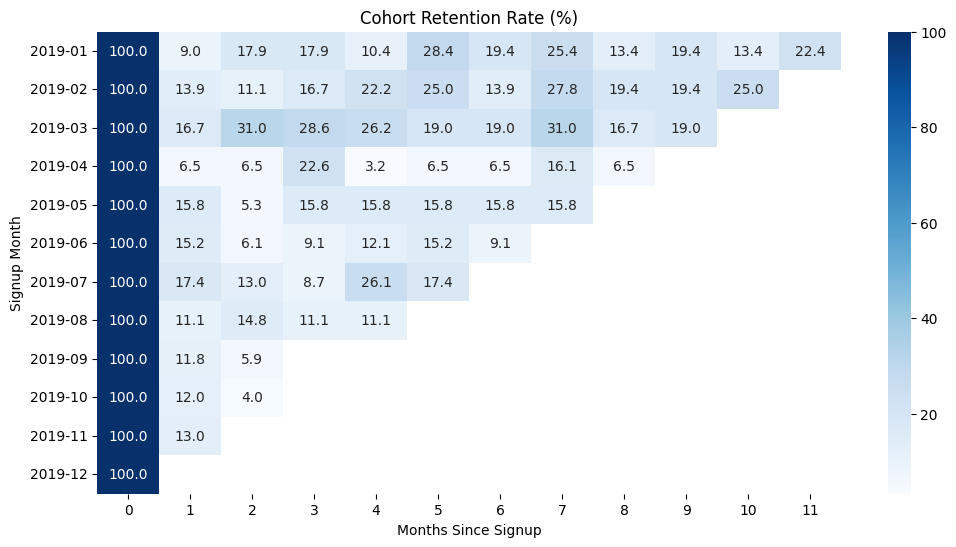

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.heatmap(retention, annot=True, fmt='.1f', cmap='Blues')
plt.title('Cohort Retention Rate (%)')
plt.xlabel('Months Since Signup')
plt.ylabel('Signup Month')
plt.show()

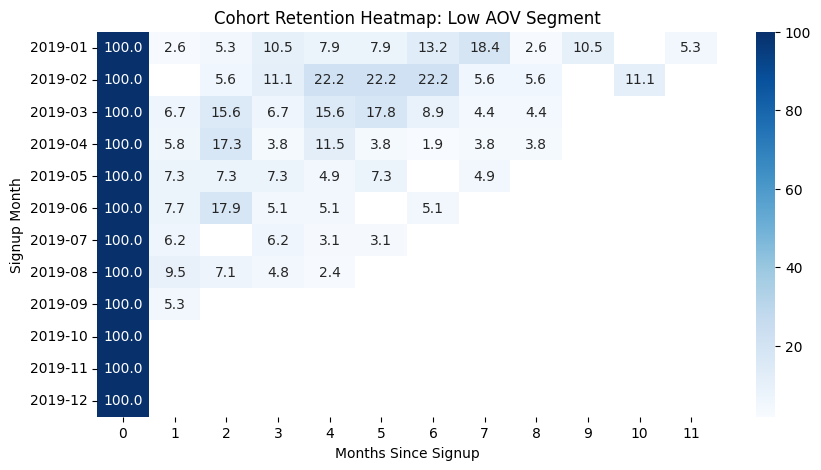

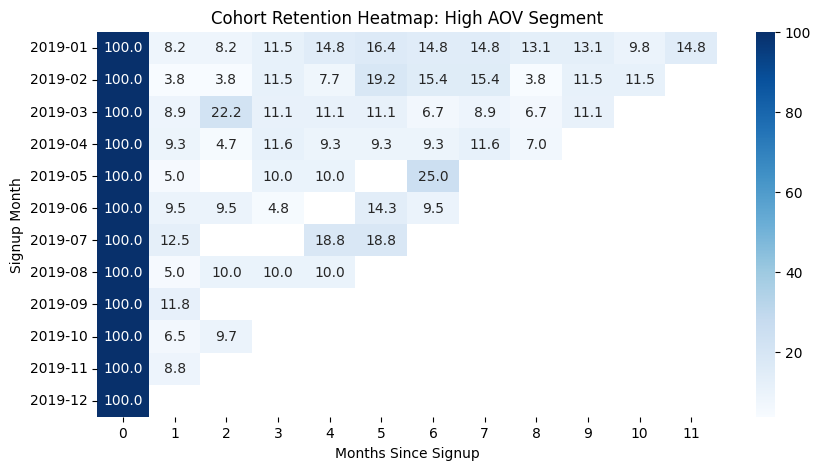

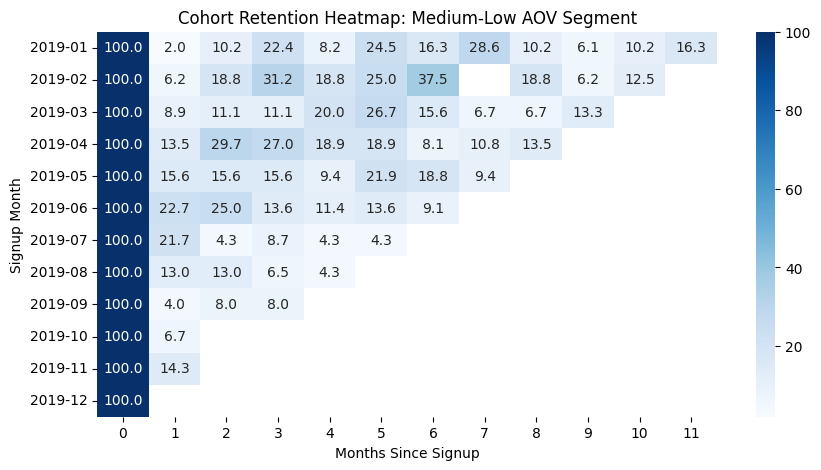

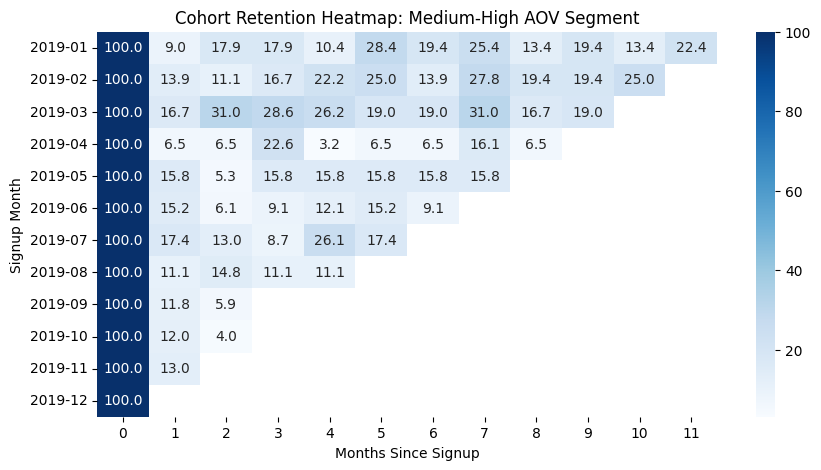

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

# Loop through each AOV segment and plot a heatmap
for seg in mart_all_data['AOV_segment'].dropna().unique():
    sub = mart_all_data[mart_all_data['AOV_segment'] == seg]
    cohort_counts = (
        sub.groupby(['signup_month', 'cohort_index'])['customer_id']
        .nunique()
        .reset_index()
        .pivot(index='signup_month', columns='cohort_index', values='customer_id')
    )
    cohort_size = cohort_counts.iloc[:, 0]
    retention = cohort_counts.divide(cohort_size, axis=0).round(3) * 100
    
    plt.figure(figsize=(10, 5))
    sns.heatmap(retention, annot=True, fmt='.1f', cmap='Blues')
    plt.title(f'Cohort Retention Heatmap: {seg} AOV Segment')
    plt.xlabel('Months Since Signup')
    plt.ylabel('Signup Month')
    plt.show()

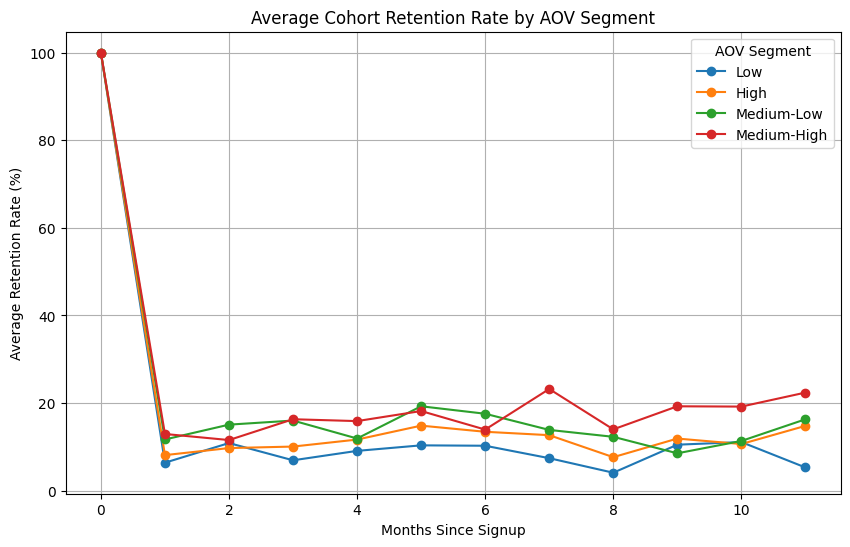

In [49]:
#Plot All Segments Together (Average Retention by Cohort Index)
plt.figure(figsize=(10, 6))

for seg in mart_all_data['AOV_segment'].dropna().unique():
    sub = mart_all_data[mart_all_data['AOV_segment'] == seg]
    cohort_counts = (
        sub.groupby(['signup_month', 'cohort_index'])['customer_id']
        .nunique()
        .reset_index()
        .pivot(index='signup_month', columns='cohort_index', values='customer_id')
    )
    cohort_size = cohort_counts.iloc[:, 0]
    retention = cohort_counts.divide(cohort_size, axis=0).round(3) * 100
    avg_retention = retention.mean(axis=0)
    plt.plot(avg_retention.index, avg_retention.values, marker='o', label=f"{seg}")

plt.title('Average Cohort Retention Rate by AOV Segment')
plt.xlabel('Months Since Signup')
plt.ylabel('Average Retention Rate (%)')
plt.legend(title='AOV Segment')
plt.grid(True)
plt.show()

#Overlay Revenue-Per-Retained-Customer by Cohort Period and Segment

Goal:
For each AOV segment, in each cohort month, show not just how many customers were retained, but how much (on average) they spent.

/var/folders/30/dsmll_zd0y99rxph1kl1nzc80000gp/T/ipykernel_22266/3859525220.py:51: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mart_all_data.groupby(['AOV_segment', 'signup_month', 'cohort_index'])


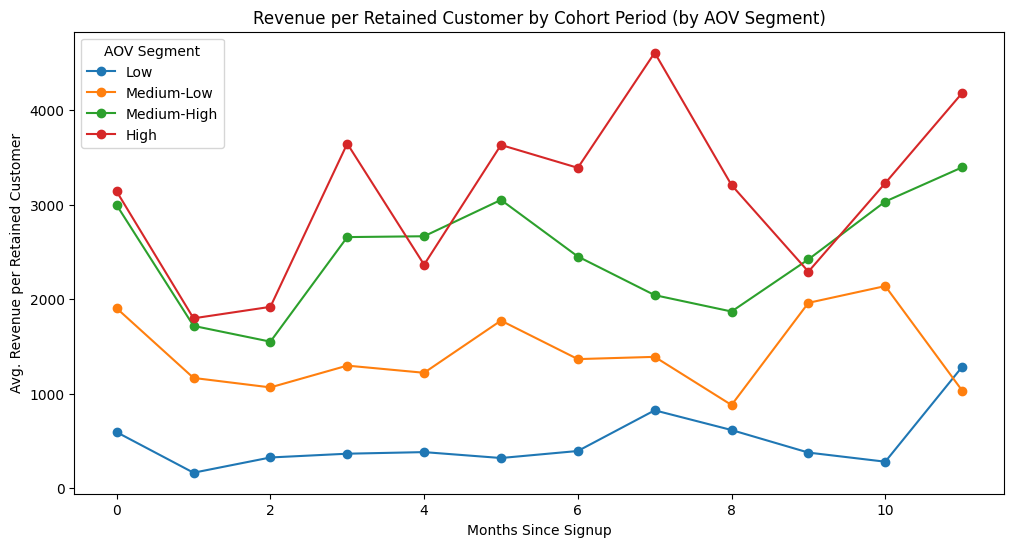

/var/folders/30/dsmll_zd0y99rxph1kl1nzc80000gp/T/ipykernel_22266/3859525220.py:81: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mart_all_data.groupby(['AOV_segment', 'signup_month', 'cohort_index'])
/var/folders/30/dsmll_zd0y99rxph1kl1nzc80000gp/T/ipykernel_22266/3859525220.py:87: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = cum_rev.pivot_table(index=['signup_month','cohort_index'],


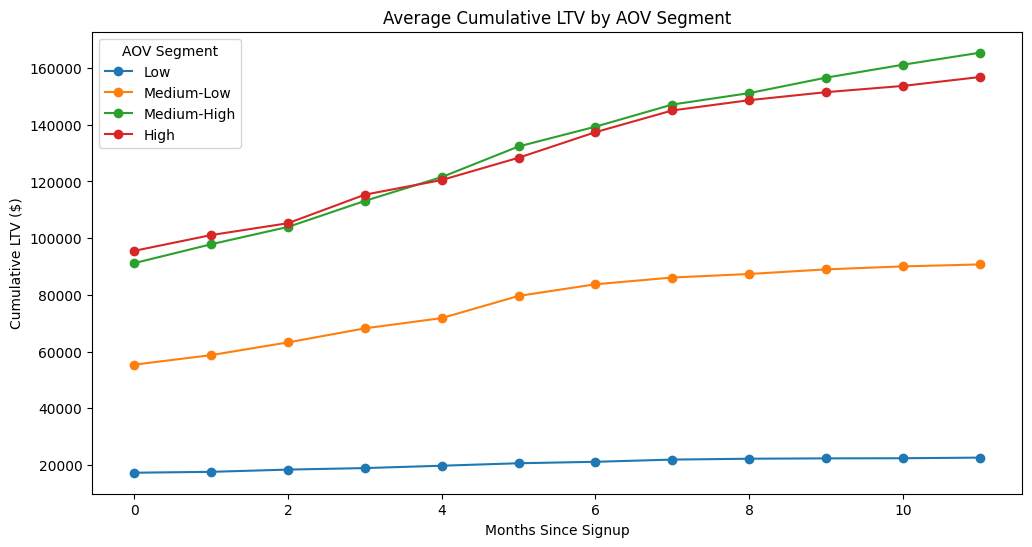

In [53]:
# Group by segment, signup month, and cohort index
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# a) Datetime
mart_all_data['transaction_date'] = pd.to_datetime(mart_all_data['transaction_date'])

# b) Revenue column to use (pick what's available or build it)
if 'invoice_value' in mart_all_data.columns:
    revenue_col = 'invoice_value'
elif 'revenue' in mart_all_data.columns:
    revenue_col = 'revenue'
else:
    # try to construct a final price if possible
    gross = mart_all_data.get('quantity', 1) * mart_all_data.get('avg_price', 0)
    disc = gross * (mart_all_data.get('discount_pct', 0) / 100.0)
    net_subtotal = gross - disc
    pre_tax = net_subtotal + mart_all_data.get('delivery_charges', 0)
    gst = pre_tax * (mart_all_data.get('gst_onsale', 0) / 100.0)
    mart_all_data['invoice_value'] = pre_tax + gst
    revenue_col = 'invoice_value'

# c) Cohort fields (signup_month and cohort_index)
#    signup_month = month of first purchase
first_dt = mart_all_data.groupby('customer_id')['transaction_date'].transform('min')
mart_all_data['signup_month'] = first_dt.dt.to_period('M').astype(str)

# months since signup (integer)
t_year = mart_all_data['transaction_date'].dt.year
t_mon  = mart_all_data['transaction_date'].dt.month
s_year = pd.to_datetime(mart_all_data['signup_month']).dt.year
s_mon  = pd.to_datetime(mart_all_data['signup_month']).dt.month
mart_all_data['cohort_index'] = (t_year - s_year) * 12 + (t_mon - s_mon)

# d) AOV_segment (if you don’t already have it)
if 'AOV_segment' not in mart_all_data.columns:
    per_cust = (
        mart_all_data.groupby('customer_id')
        .agg(rev=(revenue_col, 'sum'), orders=('transaction_id', 'nunique'))
        .reset_index()
    )
    per_cust['AOV'] = per_cust['rev'] / per_cust['orders'].replace(0, np.nan)
    per_cust['AOV_segment'] = pd.qcut(per_cust['AOV'].fillna(0), q=4,
                                      labels=['Low','Medium-Low','Medium-High','High'])
    mart_all_data = mart_all_data.merge(per_cust[['customer_id','AOV_segment']], on='customer_id', how='left')

# --- 1) Revenue per retained customer (by segment & cohort_index) ---

revenue_per_retained = (
    mart_all_data.groupby(['AOV_segment', 'signup_month', 'cohort_index'])
    .agg(
        total_revenue=(revenue_col, 'sum'),
        n_retained=('customer_id', 'nunique')
    )
    .reset_index()
)

# avoid div-by-zero
revenue_per_retained['rev_per_retained'] = (
    revenue_per_retained['total_revenue'] / revenue_per_retained['n_retained'].replace(0, np.nan)
)

# Plot average across cohorts per segment
plt.figure(figsize=(12,6))
for seg in revenue_per_retained['AOV_segment'].dropna().unique():
    sub = revenue_per_retained[revenue_per_retained['AOV_segment'] == seg]
    avg_by_index = sub.groupby('cohort_index')['rev_per_retained'].mean()
    plt.plot(avg_by_index.index, avg_by_index.values, marker='o', label=str(seg))

plt.title('Revenue per Retained Customer by Cohort Period (by AOV Segment)')
plt.xlabel('Months Since Signup')
plt.ylabel('Avg. Revenue per Retained Customer')
plt.legend(title='AOV Segment')
plt.show()

# --- 2) Cumulative LTV curves (average cumulative spend per customer, by segment) ---

# total revenue by (segment, cohort) per cohort month
cum_rev = (
    mart_all_data.groupby(['AOV_segment', 'signup_month', 'cohort_index'])
    .agg(total_revenue=(revenue_col, 'sum'))
    .reset_index()
)

# pivot: rows=(signup_month, cohort_index), cols=AOV_segment
pivot = cum_rev.pivot_table(index=['signup_month','cohort_index'],
                            columns='AOV_segment',
                            values='total_revenue',
                            fill_value=0)

# cumulative over cohort months within each signup cohort
cum_ltv = pivot.groupby(level=0).cumsum()  # cumulative along cohort_index within each signup_month

# now average across cohorts at each cohort_index for each segment
plt.figure(figsize=(12,6))
for seg in pivot.columns:
    series = cum_ltv[seg].reset_index().groupby('cohort_index')[seg].mean()
    plt.plot(series.index, series.values, marker='o', label=str(seg))

plt.title('Average Cumulative LTV by AOV Segment')
plt.xlabel('Months Since Signup')
plt.ylabel('Cumulative LTV ($)')
plt.legend(title='AOV Segment')
plt.show()